In [1]:
import sys
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('../.'))


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from xso.parscans import run_xso_parscan, run_xso_stabilityscan

from np_setups import (
    phyto_esd, n_classes,
    model_closed, model_open,
    model_setup_closed_const,   model_setup_closed_const_stability,
    model_setup_closed_allom,   model_setup_closed_allom_stability,
    model_setup_open_const,     model_setup_open_const_stability,
    model_setup_open_allom,     model_setup_open_allom_stability,
)

# Scan ranges and parscan workers
N_PROCESSES = 12
AVG_WINDOW  = 1000

N_T_VALUES = np.logspace(np.log10(0.01), np.log10(50.0),  10)
F_N_VALUES = np.logspace(np.log10(0.1),  np.log10(25.0),  10)

print(f"Grid: {n_classes} classes, ESD range "
      f"[{phyto_esd[0]:.3f}, {phyto_esd[-1]:.1f}] µm")
print(f"Closed scan (N_T): {N_T_VALUES[0]:.3f} – {N_T_VALUES[-1]:.1f} "
      f"mmol N m⁻³, {len(N_T_VALUES)} pts")
print(f"Open scan (F_N): {F_N_VALUES[0]:.3f} – {F_N_VALUES[-1]:.1f} "
      f"mmol N m⁻² d⁻¹, {len(F_N_VALUES)} pts")

Grid: 40 classes, ESD range [0.200, 200.0] µm
Closed scan (N_T): 0.010 – 50.0 mmol N m⁻³, 10 pts
Open scan (F_N): 0.100 – 25.0 mmol N m⁻² d⁻¹, 10 pts


In [2]:
def run_np_scan(model_name, ivp_setup_name, stability_setup_name,
                param_name, param_values,
                processes=N_PROCESSES, avg_window=AVG_WINDOW,
                neg_tol=-1e-9):
    """Run IVP parscan → tail-mean seed → stability parscan for an N-P variant.

    Diagnostics: after the IVP scan, reports any state-variable tail-mean
    entries below `neg_tol` (default −1e-9). XSO's solve_ivp wrapper
    auto-terminates at < −1e-6 (XSO_HANDOFF §11), so values surviving
    that floor sit in (−1e-6, 0); this check catches the in-between
    range where the spectrum has slipped meaningfully negative through
    accumulated numerical noise.

    Returns (ivp_results, stability_results); stability_results is None
    if all IVP cells failed (no valid seed to inject into fsolve).
    """

    ivp_results = run_xso_parscan(
        model_file_name='np_setups',
        model_name=model_name,
        model_setup_name=ivp_setup_name,
        param_name=param_name,
        param_values=param_values,
        processes=processes,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': avg_window},
    )

    state_vars = ['Nutrient__value', 'Phytoplankton__biomass']
    if not all(v in ivp_results.data_vars for v in state_vars):
        print(f"  [skip stability] IVP scan returned empty / no state vars")
        return ivp_results, None

    # Tail-mean = the avg_tail postprocess output (single time-step).
    seed_ds = (ivp_results[state_vars]
               .isel(time=slice(-avg_window, None)).mean('time'))

    # --- Negative-value diagnostic ---
    print(f"  Negative-value check on tail-mean (neg_tol = {neg_tol:.0e}):")
    any_neg = False
    for v in state_vars:
        arr = seed_ds[v].values
        n_neg = int(np.sum(arr < neg_tol))
        n_tot = int(np.size(arr))
        if n_neg > 0:
            any_neg = True
            worst = float(np.nanmin(arr))
            n_below_xso_floor = int(np.sum(arr < -1e-6))
            print(f"    {v}: {n_neg}/{n_tot} entries < {neg_tol:.0e}, "
                  f"worst = {worst:.2e}"
                  + (f", {n_below_xso_floor} of those past XSO −1e-6 floor"
                     if n_below_xso_floor > 0 else ""))
    if not any_neg:
        print(f"    all tail-mean entries ≥ {neg_tol:.0e}  ✓")

    # Apply strict-positivity floor before fsolve
    FLOOR = 1e-12
    for v in state_vars:
        seed_ds[v] = seed_ds[v].where(seed_ds[v] > FLOOR, FLOOR)
    iv_mapping = {v: v + '_init' for v in state_vars}

    stability_results = run_xso_stabilityscan(
        model_file_name='np_setups',
        model_name=model_name,
        model_setup_name=stability_setup_name,
        param_name=param_name,
        param_values=param_values,
        processes=processes,
        initial_values_ds=seed_ds, iv_mapping=iv_mapping,
    )
    return ivp_results, stability_results

In [4]:
def run_np_scan(model_name, ivp_setup_name, stability_setup_name,
                param_name, param_values,
                processes=N_PROCESSES, avg_window=AVG_WINDOW):
    """Run IVP parscan → tail-mean seed → stability parscan for an N-P variant.

    Returns (ivp_results, stability_results); stability_results is None
    if all IVP cells failed (no valid seed to inject).
    """

    ivp_results = run_xso_parscan(
        model_file_name='np_setups',
        model_name=model_name,
        model_setup_name=ivp_setup_name,
        param_name=param_name,
        param_values=param_values,
        processes=processes,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': avg_window},
    )

    state_vars = ['Nutrient__value', 'Phytoplankton__biomass']
    if not all(v in ivp_results.data_vars for v in state_vars):
        print(f"  [skip stability] IVP scan returned empty / no state vars")
        return ivp_results, None

    FLOOR = 1e-12
    seed_ds = (ivp_results[state_vars]
               .isel(time=slice(-avg_window, None)).mean('time'))
    for v in state_vars:
        seed_ds[v] = seed_ds[v].where(seed_ds[v] > FLOOR, FLOOR)
    iv_mapping = {v: v + '_init' for v in state_vars}

    stability_results = run_xso_stabilityscan(
        model_file_name='np_setups',
        model_name=model_name,
        model_setup_name=stability_setup_name,
        param_name=param_name,
        param_values=param_values,
        processes=processes,
        initial_values_ds=seed_ds, iv_mapping=iv_mapping,
    )
    return ivp_results, stability_results

In [4]:
import time
from np_setups import model_closed, model_setup_closed_const
t0 = time.time()
with model_closed:
    out = model_setup_closed_const.xsimlab.run()
print(f"single closed-const IVP, 5000 d, 40 classes: {time.time()-t0:.1f} s")

single closed-const IVP, 5000 d, 40 classes: 25.2 s


In [3]:
SCAN_CLOSED_PARAM = 'Nutrient__value_init'
SCAN_OPEN_PARAM   = 'FN_Forcing__value'

results = {}

print("--- closed-const ---")
results['closed_const'] = run_np_scan(
    'model_closed', 'model_setup_closed_const', 'model_setup_closed_const_stability',
    SCAN_CLOSED_PARAM, N_T_VALUES)

print("--- closed-allom ---")
results['closed_allom'] = run_np_scan(
    'model_closed', 'model_setup_closed_allom', 'model_setup_closed_allom_stability',
    SCAN_CLOSED_PARAM, N_T_VALUES)

print("--- open-const ---")
results['open_const'] = run_np_scan(
    'model_open', 'model_setup_open_const', 'model_setup_open_const_stability',
    SCAN_OPEN_PARAM, F_N_VALUES)

print("--- open-allom ---")
results['open_allom'] = run_np_scan(
    'model_open', 'model_setup_open_allom', 'model_setup_open_allom_stability',
    SCAN_OPEN_PARAM, F_N_VALUES)

print("Done.")

--- closed-const ---
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_closed' and setup 'model_setup_closed_const' from 'np_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'np_setups' over 10 points using 12 workers...
1D Scan complete. Time taken: 90.8956 seconds.
  Negative-value check on tail-mean (neg_tol = -1e-09):
    all tail-mean entries ≥ -1e-09  ✓
--- Starting Stability Scan ---
Validating model 'model_closed' and setup 'model_setup_closed_const_stability' from 'np_setups'...
Validation successful. Proceeding with scan.
Injecting initial values from dataset using mapping: {'Nutrient__value': 'Nutrient__value_init', 'Phytoplankton__biomass': 'Phytoplankton__biomass_init'}
--------------------------------
Starting 1D stability scan of 'np_setups' over 10 points using 12 workers...
1D Stability Scan complete. Time taken: 2.76145 seconds.
--- closed-allom ---
--- St

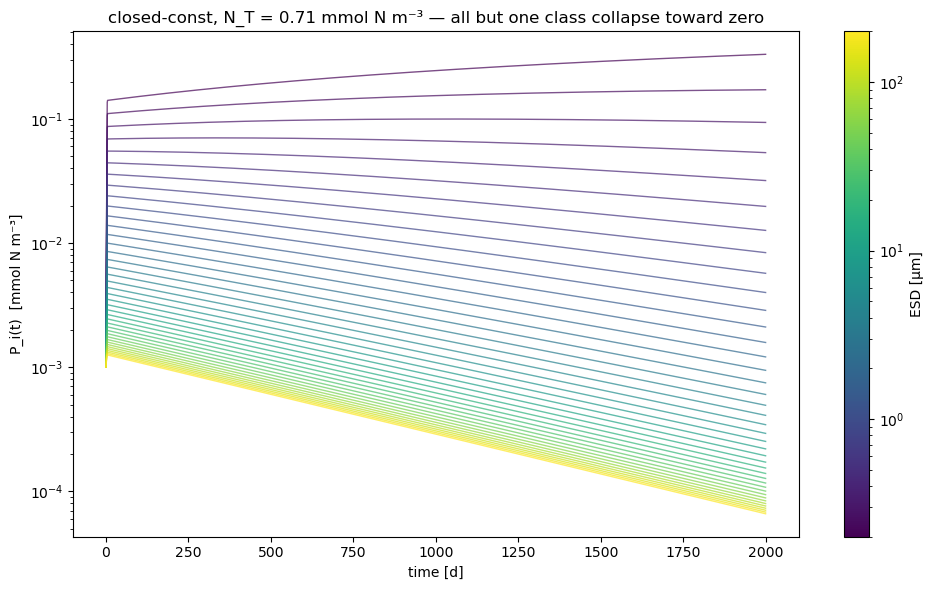

In [5]:
ivp_cc, _ = results['closed_const']

# Wait — the IVP results from a parscan with avg_tail postprocess have time
# collapsed to length 1, so we can't get a time-series. Re-run a single
# IVP at a chosen N_T directly via xsimlab.run() instead.
with model_closed:
    N_T_demo = float(np.sqrt(N_T_VALUES[0] * N_T_VALUES[-1]))  # geometric mean
    demo_run = (model_setup_closed_const
                .xsimlab.update_vars(input_vars={
                    'Nutrient': {'value_init': N_T_demo},
                })
                .xsimlab.run())

P_t = demo_run.Phytoplankton__biomass.transpose('time', 'phyto').values
t   = demo_run.time.values
ess = demo_run.phyto.values

fig, ax = plt.subplots(figsize=(10, 6))
norm = mcolors.LogNorm(vmin=ess.min(), vmax=ess.max())
cmap = plt.get_cmap('viridis')
for i in range(n_classes):
    ax.plot(t, np.maximum(P_t[:, i], 1e-15),
            color=cmap(norm(ess[i])), alpha=0.7, lw=1)
ax.set_yscale('log')
ax.set_xlabel('time [d]')
ax.set_ylabel('P_i(t)  [mmol N m⁻³]')
ax.set_title(f'closed-const, N_T = {N_T_demo:.2f} mmol N m⁻³ — '
             f'all but one class collapse toward zero')
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, ax=ax, label='ESD [µm]')
plt.tight_layout()
plt.show()

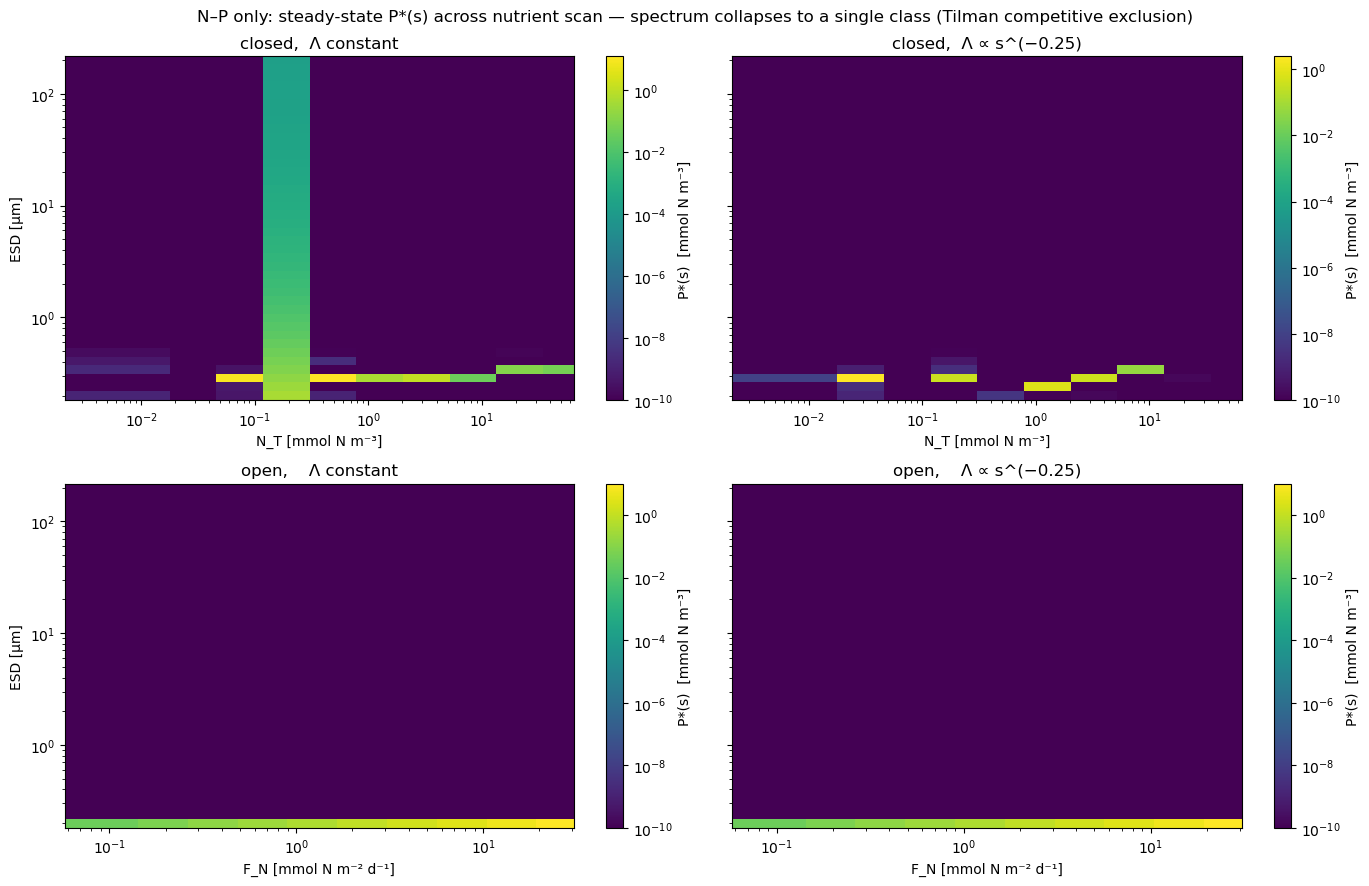

In [6]:
SCAN_AXIS = {
    'closed_const': (N_T_VALUES, 'N_T [mmol N m⁻³]', 'closed,  Λ constant'),
    'closed_allom': (N_T_VALUES, 'N_T [mmol N m⁻³]', 'closed,  Λ ∝ s^(−0.25)'),
    'open_const':   (F_N_VALUES, 'F_N [mmol N m⁻² d⁻¹]', 'open,    Λ constant'),
    'open_allom':   (F_N_VALUES, 'F_N [mmol N m⁻² d⁻¹]', 'open,    Λ ∝ s^(−0.25)'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
flat = axes.flatten()

for ax, (key, (xvals, xlab, title)) in zip(flat, SCAN_AXIS.items()):
    _, stab = results[key]
    if stab is None:
        ax.text(0.5, 0.5, 'scan failed', transform=ax.transAxes,
                ha='center', va='center', color='C3')
        ax.set_title(title)
        continue
    P_star = stab.Phytoplankton__biomass.isel(time=-1).values
    P_star = np.maximum(P_star, 1e-15)
    im = ax.pcolormesh(
        xvals, phyto_esd, P_star.T,
        norm=mcolors.LogNorm(vmin=1e-10, vmax=max(1.0, np.nanmax(P_star))),
        cmap='viridis', shading='auto',
    )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlab)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='P*(s)  [mmol N m⁻³]')

for ax in axes[:, 0]:
    ax.set_ylabel('ESD [µm]')

fig.suptitle('N–P only: steady-state P*(s) across nutrient scan — '
             'spectrum collapses to a single class (Tilman competitive exclusion)',
             fontsize=12)
plt.tight_layout()
plt.show()

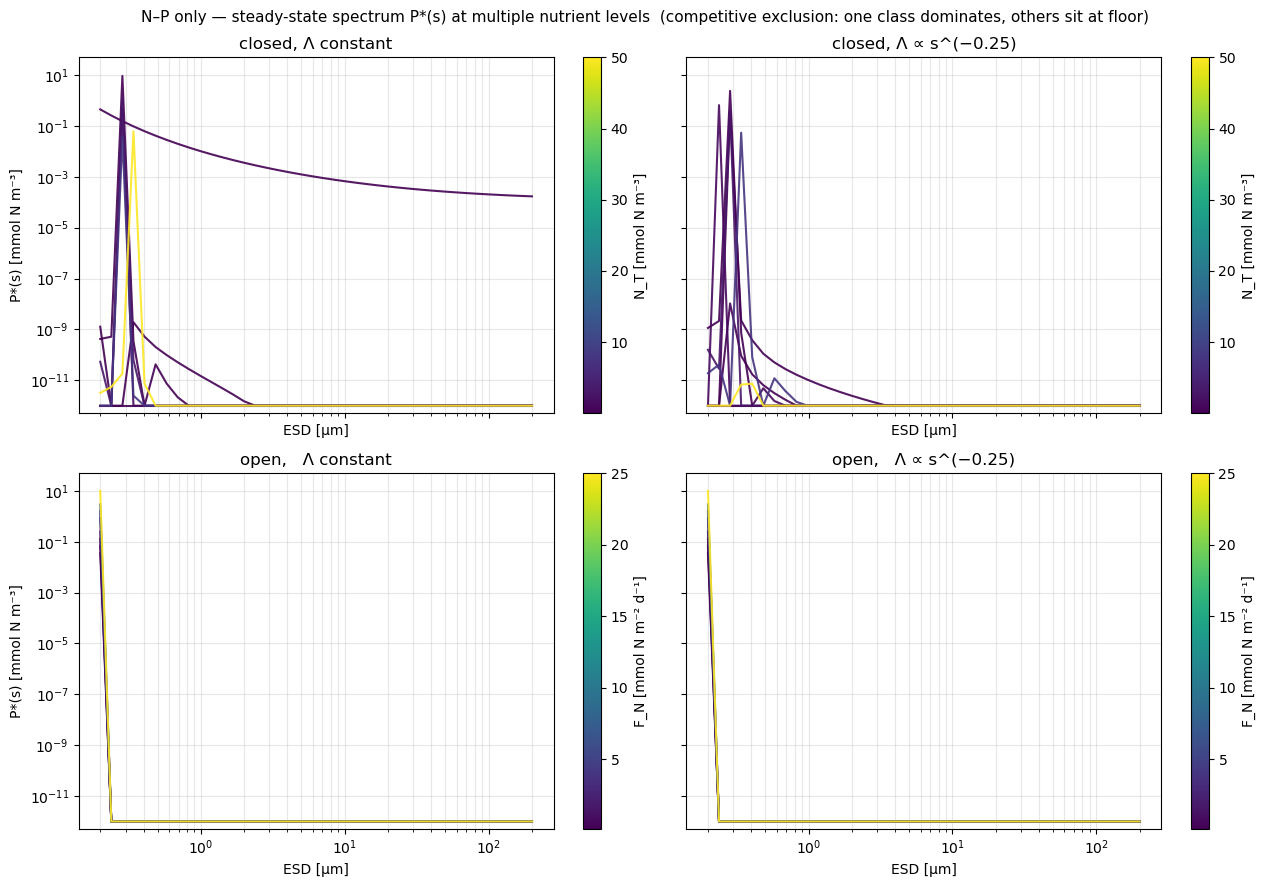

In [8]:
N_LINES = 8  # number of representative spectra per panel

SCAN_AXIS = {
    'closed_const': (N_T_VALUES, 'N_T [mmol N m⁻³]',        'closed, Λ constant'),
    'closed_allom': (N_T_VALUES, 'N_T [mmol N m⁻³]',        'closed, Λ ∝ s^(−0.25)'),
    'open_const':   (F_N_VALUES, 'F_N [mmol N m⁻² d⁻¹]',    'open,   Λ constant'),
    'open_allom':   (F_N_VALUES, 'F_N [mmol N m⁻² d⁻¹]',    'open,   Λ ∝ s^(−0.25)'),
}

P_FLOOR = 1e-12   # visualisation floor (anything below is "dead")

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
flat = axes.flatten()

for ax, (key, (xvals, xlab, title)) in zip(flat, SCAN_AXIS.items()):
    _, stab = results[key]
    if stab is None:
        ax.text(0.5, 0.5, 'scan failed', transform=ax.transAxes,
                ha='center', va='center', color='C3')
        ax.set_title(title)
        continue

    P_star = stab.Phytoplankton__biomass.isel(time=-1).values   # (scan, phyto)
    P_star = np.maximum(P_star, P_FLOOR)                        # show floor explicitly

    # Evenly-spaced scan indices so we see ~N_LINES representative spectra
    idxs = np.linspace(0, len(xvals) - 1, N_LINES).astype(int)
    cmap = plt.get_cmap('viridis')
    norm = mcolors.Normalize(vmin=xvals.min(), vmax=xvals.max())  # linear color

    for i in idxs:
        ax.plot(phyto_esd, P_star[i, :], '-',
                color=cmap(norm(xvals[i])), lw=1.5, alpha=0.9)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('ESD [µm]')
    ax.set_title(title)
    ax.set_ylim(P_FLOOR * 0.5, 50)
    ax.grid(True, which='both', alpha=0.3)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    plt.colorbar(sm, ax=ax, label=xlab)

for ax in axes[:, 0]:
    ax.set_ylabel('P*(s) [mmol N m⁻³]')

fig.suptitle('N–P only — steady-state spectrum P*(s) at multiple nutrient levels  '
             '(competitive exclusion: one class dominates, others sit at floor)',
             fontsize=11)
plt.tight_layout()
plt.show()